# Exploratory Data Analysis 1: First Look

In [1]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from dotenv import load_dotenv
from matplotlib.ticker import MaxNLocator

In [3]:
load_dotenv('../.env')

True

In [4]:
movies_df = pd.read_csv('../datasets/ml-25m/movies.csv')
ratings_df = pd.read_csv('../datasets/ml-25m/ratings.csv', parse_dates=['timestamp'])
tags_df = pd.read_csv('../datasets/ml-25m/tags.csv')
genome_scores_df = pd.read_csv('../datasets/ml-25m/genome-scores.csv')
genome_tags_df = pd.read_csv('../datasets/ml-25m/genome-tags.csv')
links_df = pd.read_csv('../datasets/ml-25m/links.csv')

C:\Users\taaha\AppData\Local\Temp\ipykernel_46040\4272840921.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ratings_df = pd.read_csv('../datasets/ml-25m/ratings.csv', parse_dates=['timestamp'])


## Dataset Exploration Helpers

In [5]:
from io import StringIO

from IPython.display import Markdown, display


def dataset_statistics(df: pd.DataFrame, name: str = "Dataset") -> None:
    """
    Report basic statistics about the dataset (Jupyter-friendly: Markdown + HTML tables).
    """
    # Print the shape of the Dataset
    display(Markdown(f"## {name}"))
    display(
        Markdown(
            f"**Rows:** {df.shape[0]:,} &nbsp;·&nbsp; **Columns:** {df.shape[1]:,}"
        )
    )

    display(Markdown("---"))

    # Print extra information about the dataset include column names, non-null counts, dtypes
    display(Markdown("### Column names, non-null counts, dtypes"))
    buf = StringIO()
    df.info(buf=buf, verbose=True)
    display(Markdown("```text\n" + buf.getvalue() + "\n```"))

    display(Markdown("---"))

    # Print the first 5 rows of the dataset
    display(Markdown("### First 5 rows"))
    display(df.head())

    display(Markdown("---"))

    # Print the unique values per column
    display(Markdown("### Unique values per column"))
    display(df.nunique(dropna=True).rename("nunique").to_frame())

    display(Markdown("---"))

    # Print the missing values (count and % of rows)
    display(Markdown("### Missing values (count and % of rows)"))
    missing = pd.DataFrame(
        {"missing": df.isna().sum(), "pct_rows": (100 * df.isna().mean()).round(2)}
    )
    display(missing)

    display(Markdown("---"))

    # Print the duplicate rows (count and % of rows)
    display(Markdown("### Duplicate rows (identical full row)"))
    dup = int(df.duplicated().sum())
    frac = dup / len(df) if len(df) else 0.0
    display(
        Markdown(
            f"**Count:** `{dup:,}` &nbsp;·&nbsp; **Fraction of rows:** `{frac:.6f}`"
        )
    )
    if dup > 0:
        display(df[df.duplicated()])

    display(Markdown("---"))



In [6]:
from IPython.display import Markdown, display


def numeric_columns(df: pd.DataFrame, name: str = "Dataset") -> pd.DataFrame | None:
    """Show `describe()` for numeric columns; returns the summary table (or None)."""
    numeric_df = df.select_dtypes(include="number")
    n = numeric_df.shape[1]
    if n == 0:
        display(Markdown(f"**{name}** — *no numeric columns.*"))
        return None

    display(Markdown(f"### Numeric summary — **{name}**"))
    display(Markdown(f"*{n} numeric column(s), {len(numeric_df):,} rows*"))

    summary = numeric_df.describe().T.round(4)
    summary.insert(0, "dtype", numeric_df.dtypes.astype(str))
    display(summary)
    return summary



In [7]:
numeric_columns(movies_df)

### Numeric summary — **Dataset**

*1 numeric column(s), 62,423 rows*

,dtype,count,mean,std,min,25%,50%,75%,max
movieId,int64,62423.0,122220.3876,63264.7448,1.0,82146.5,138022.0,173222.0,209171.0


,dtype,count,mean,std,min,25%,50%,75%,max
movieId,int64,62423.0,122220.3876,63264.7448,1.0,82146.5,138022.0,173222.0,209171.0


# Basic Exploration

### Dataset Exploration

- Looks like we need to fetch more information about a movie such as the movie summary.
- We should use the TMDB API.
- MovieId is always unique but some movie titles are repeated. So we should do any joins on movie id only.

In [8]:
dataset_statistics(movies_df, "Movies Dataset")

## Movies Dataset

**Rows:** 62,423 &nbsp;·&nbsp; **Columns:** 3

---

### Column names, non-null counts, dtypes

```text
<class 'pandas.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  62423 non-null  int64
 1   title    62423 non-null  str  
 2   genres   62423 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.4 MB

```

...

,missing,pct_rows
movieId,0,0.0
title,0,0.0
genres,0,0.0


---

### Duplicate rows (identical full row)

**Count:** `0` &nbsp;·&nbsp; **Fraction of rows:** `0.000000`

---

### Custom Data Exploration

#### Repeated Movie Titles

In [9]:
print(len(movies_df['movieId']) - movies_df['movieId'].nunique())
print(len(movies_df['title']) - movies_df['title'].nunique())

0
98


In [10]:
movies_df[movies_df['title'].duplicated(keep=False)]

,movieId,title,genres
580,588,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical
1710,1788,Men with Guns (1997),Action|Drama
2553,2644,Dracula (1931),Horror
2759,2851,Saturn 3 (1980),Adventure|Sci-Fi|Thriller
3454,3553,Gossip (2000),Drama|Thriller
...,...,...,...
61525,206125,Lost & Found (2018),Comedy|Drama
61697,206674,Camino (2016),Comedy
61714,206712,American Woman (2019),(no genres listed)
61800,206925,The Plague (2006),Documentary


### Movie Genre Distribution

<Axes: >

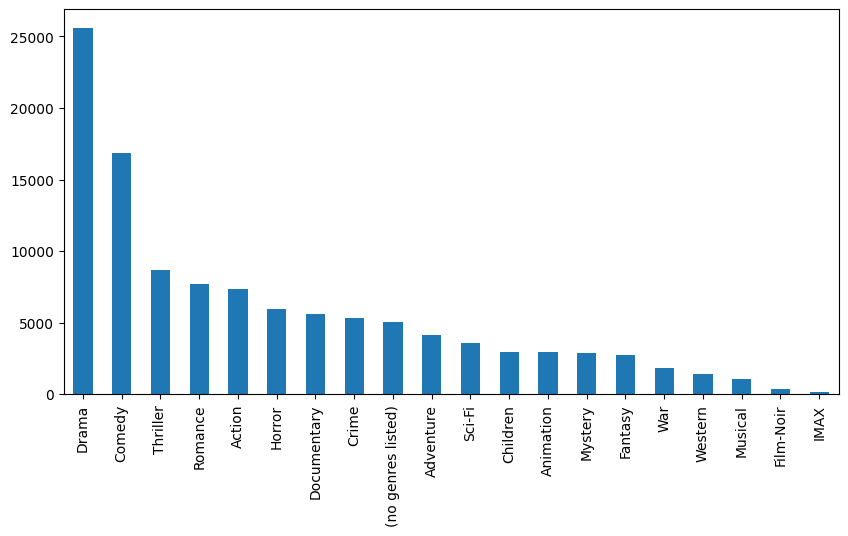

In [11]:
genres = movies_df['genres'].str.split('|', expand=True).stack()
genres.value_counts()
genres.value_counts().plot(kind='bar', figsize=(10, 5))

### Movies by Release Year

In [12]:
y = movies_df["title"].str.extract(r"\((\d{4})\)\s*$", expand=True)[0]
year = pd.to_numeric(y, errors="coerce")

# MovieLens is mostly ~1900–2019;
ok = year.between(1888, 2026)

movies_clean = movies_df.loc[ok].copy()
movies_clean["year"] = year.loc[ok].astype(int)


print(f"The number of movies in the dataset is {len(movies_df)}, the number of movies with a release year is {len(movies_clean['year'])}. The difference is {len(movies_df) - len(movies_clean['year'])}")

The number of movies in the dataset is 62423, the number of movies with a release year is 62006. The difference is 417


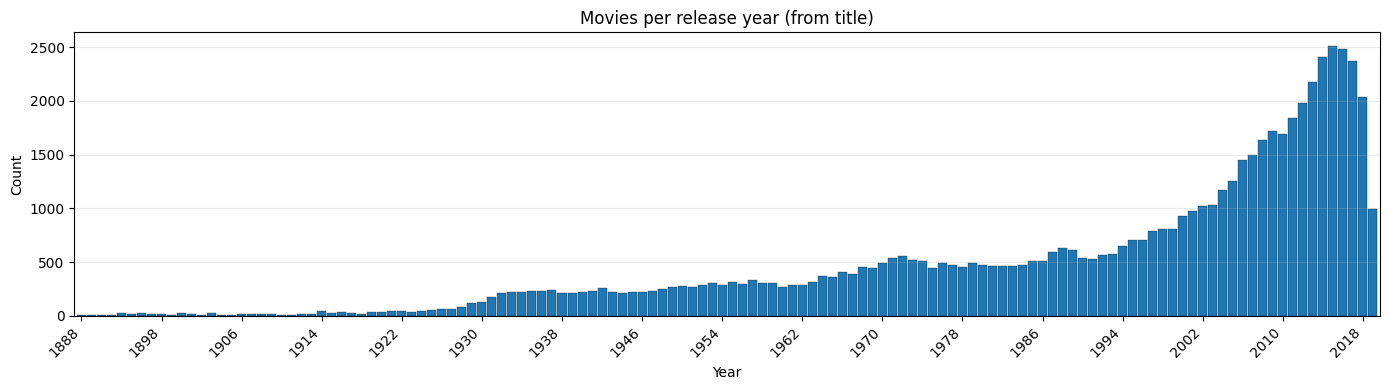

In [13]:
vc = movies_clean["year"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(14, 4))
vc.plot(kind="bar", ax=ax, width=0.9, edgecolor="black", linewidth=0.2)
ax.set_title("Movies per release year (from title)")
ax.set_xlabel("Year")
ax.set_ylabel("Count")
# Don’t label every year if crowded
ax.xaxis.set_major_locator(MaxNLocator(nbins=18, prune=None))
plt.xticks(rotation=45, ha="right")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()

### Average Number of Genres per Movie

In [14]:
new_movie_df = movies_df.copy()
new_movie_df['genres'] = new_movie_df['genres'].replace('(no genres listed)', np.nan)
genres_count = new_movie_df['genres'].str.split('|', expand=True).notna().sum(axis=1)
genres_count.mean()


np.float64(1.7180366211172164)

## Ratings Table Exploration

### Basic Exploration

In [15]:
dataset_statistics(ratings_df, "Ratings Dataset")

## Ratings Dataset

**Rows:** 25,000,095 &nbsp;·&nbsp; **Columns:** 4

---

### Column names, non-null counts, dtypes

```text
<class 'pandas.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  str    
dtypes: float64(1), int64(2), str(1)
memory usage: 762.9 MB

```

...

,missing,pct_rows
userId,0,0.0
movieId,0,0.0
rating,0,0.0
timestamp,0,0.0


---

### Duplicate rows (identical full row)

**Count:** `0` &nbsp;·&nbsp; **Fraction of rows:** `0.000000`

---

In [16]:
numeric_columns(ratings_df, "Ratings Dataset")

### Numeric summary — **Ratings Dataset**

*3 numeric column(s), 25,000,095 rows*

,dtype,count,mean,std,min,25%,50%,75%,max
userId,int64,25000095.0,81189.2812,46791.7159,1.0,40510.0,80914.0,121557.0,162541.0
movieId,int64,25000095.0,21387.9819,39198.8621,1.0,1196.0,2947.0,8623.0,209171.0
rating,float64,25000095.0,3.5339,1.0607,0.5,3.0,3.5,4.0,5.0


,dtype,count,mean,std,min,25%,50%,75%,max
userId,int64,25000095.0,81189.2812,46791.7159,1.0,40510.0,80914.0,121557.0,162541.0
movieId,int64,25000095.0,21387.9819,39198.8621,1.0,1196.0,2947.0,8623.0,209171.0
rating,float64,25000095.0,3.5339,1.0607,0.5,3.0,3.5,4.0,5.0


### How many users have rated each movie as a %?

In [17]:
len(ratings_df['rating'].dropna()) / (ratings_df['userId'].nunique() * ratings_df['movieId'].nunique())

0.002604839052572928

So for all the users and movies in our dataset, we have 0.26% of the user-movie pairs having a rating.
- Who rated what models might suffer on unusual movies and new users.
- May need to rely more on genres, summaries etc to mitigate this.
- This was expected.

### User Ratings Statistics

In [18]:
ratings_df.describe(include='float').round(2)

,rating
count,25000095.00
mean,3.53
std,1.06
min,0.50
25%,3.00
50%,3.50
75%,4.00
max,5.00


In [19]:
ratings_df['rating'].value_counts()

rating
4.0    6639798
3.0    4896928
5.0    3612474
3.5    3177318
4.5    2200539
2.0    1640868
2.5    1262797
1.0     776815
1.5     399490
0.5     393068
Name: count, dtype: int64

Text(0.5, 1.0, 'Rating Distribution')

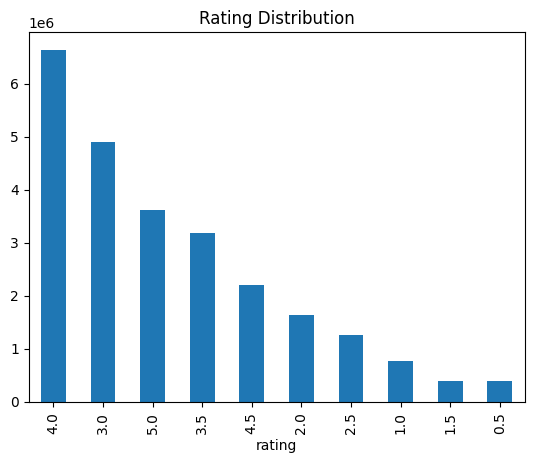

In [20]:
ratings_df['rating'].value_counts().plot(kind='bar').set_title('Rating Distribution')

### Ratings Over Time

In [21]:
ts = pd.to_numeric(ratings_df["timestamp"], errors='coerce')
ratings_df['rated_at'] = pd.to_datetime(ts, unit='s', utc=True)

<Axes: xlabel='rated_at'>

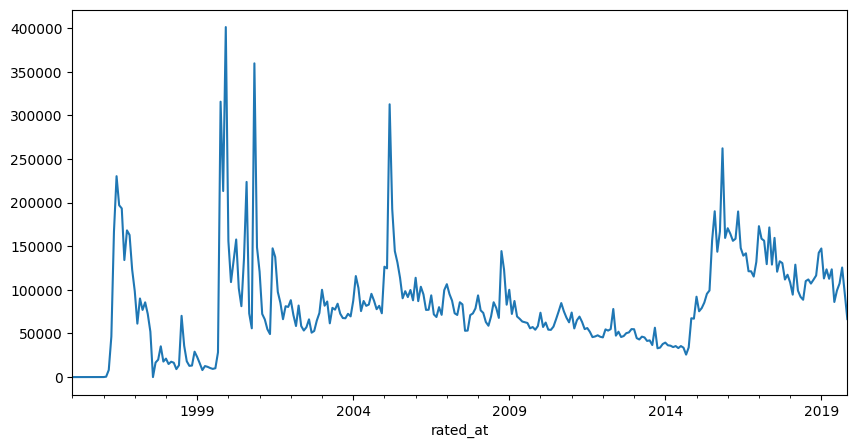

In [22]:
ratings_df.set_index("rated_at").resample("ME").size().plot(figsize=(10, 5))

### Average Ratings by each User

<Axes: title={'center': 'Average Rating for a Movie'}, ylabel='Frequency'>

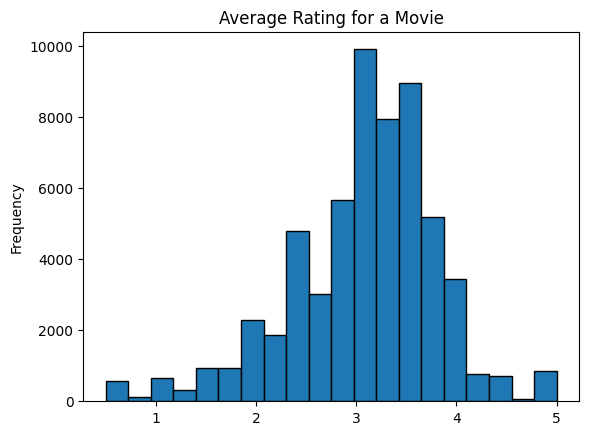

In [23]:
ratings_df.groupby("movieId")["rating"].mean().plot(kind="hist", bins=20, edgecolor="black", title="Average Rating for a Movie")


Average Ratings Overtime

<Axes: xlabel='rated_at'>

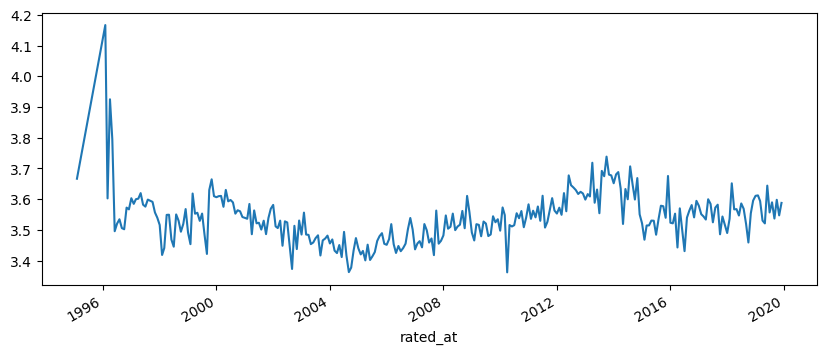

In [24]:
ratings_df.set_index("rated_at")["rating"].resample("ME").mean().dropna().plot(figsize=(10, 4))

### Per User Behaviour

<Axes: ylabel='Frequency'>

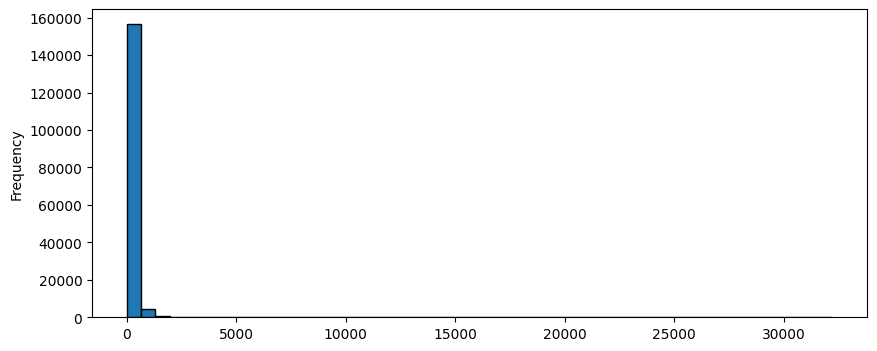

In [25]:
ratings_df.groupby("userId").size().plot(kind="hist", bins=50, edgecolor="black", figsize=(10, 4))

## Tags Table Exploration

In [26]:
dataset_statistics(tags_df, "Ratings Dataset")

## Ratings Dataset

**Rows:** 1,093,360 &nbsp;·&nbsp; **Columns:** 4

---

### Column names, non-null counts, dtypes

```text
<class 'pandas.DataFrame'>
RangeIndex: 1093360 entries, 0 to 1093359
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   userId     1093360 non-null  int64
 1   movieId    1093360 non-null  int64
 2   tag        1093344 non-null  str  
 3   timestamp  1093360 non-null  int64
dtypes: int64(3), str(1)
memory usage: 33.4 MB

```

...

,missing,pct_rows
userId,0,0.0
movieId,0,0.0
tag,16,0.0
timestamp,0,0.0


---

### Duplicate rows (identical full row)

**Count:** `0` &nbsp;·&nbsp; **Fraction of rows:** `0.000000`

---

### % Of Users that Tagged at Least One Movie

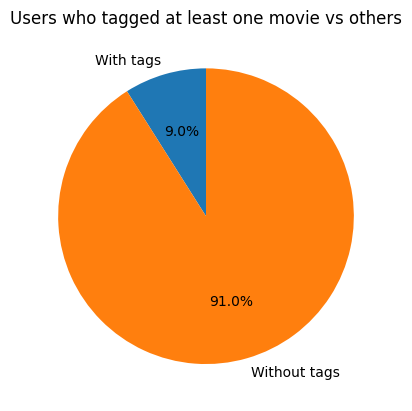

In [27]:
tagging_users = tags_df.dropna()['userId'].nunique()
total_users = ratings_df.dropna()['userId'].nunique()

sizes = [tagging_users, total_users - tagging_users]
labels = ['With tags', 'Without tags']
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Users who tagged at least one movie vs others')
plt.show()

% Of Movies That are Tagged

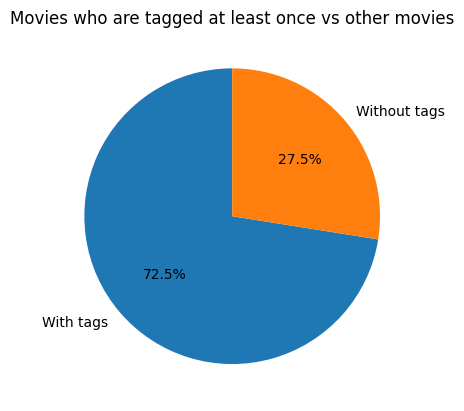

In [28]:
tagged_movies = tags_df.dropna()['movieId'].nunique()
total_movies = movies_df.dropna()['movieId'].nunique()

sizes = [tagged_movies, total_movies - tagged_movies]
labels = ['With tags', 'Without tags']
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Movies who are tagged at least once vs other movies')
plt.show()

### Number of Tags per User/Movie

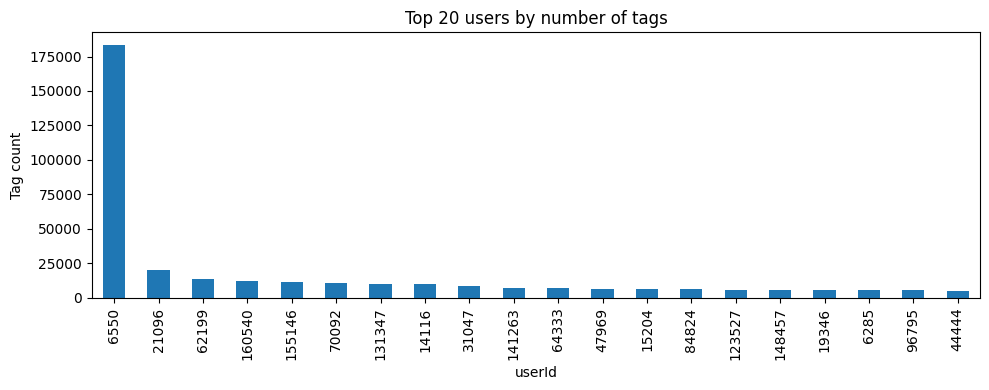

In [29]:
tags_per_user = tags_df.dropna().groupby('userId').size()
tags_per_user.nlargest(20).plot.bar(figsize=(10, 4))
plt.ylabel('Tag count')
plt.xlabel('userId')
plt.title('Top 20 users by number of tags')
plt.tight_layout()
plt.show()

Top 20 Movies by The Number of Tags

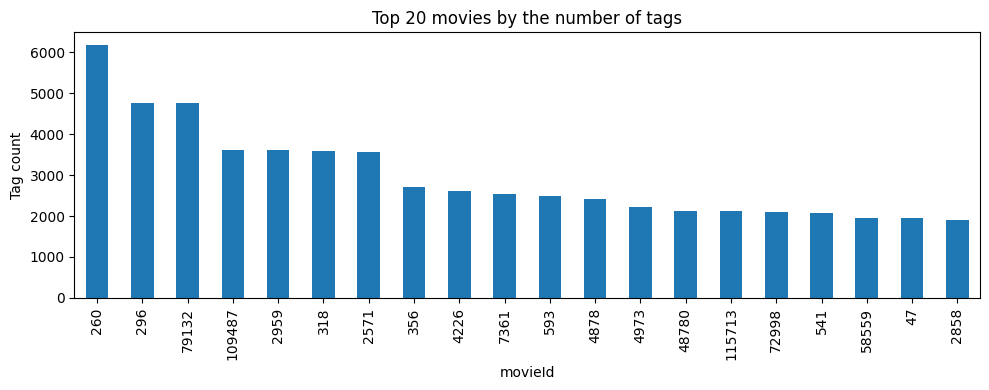

In [30]:
tags_per_user = tags_df.dropna().groupby('movieId').size()
tags_per_user.nlargest(20).plot.bar(figsize=(10, 4))
plt.ylabel('Tag count')
plt.xlabel('movieId')
plt.title('Top 20 movies by the number of tags')
plt.tight_layout()
plt.show()

### How Many Times has a User Rated the Same Movie?

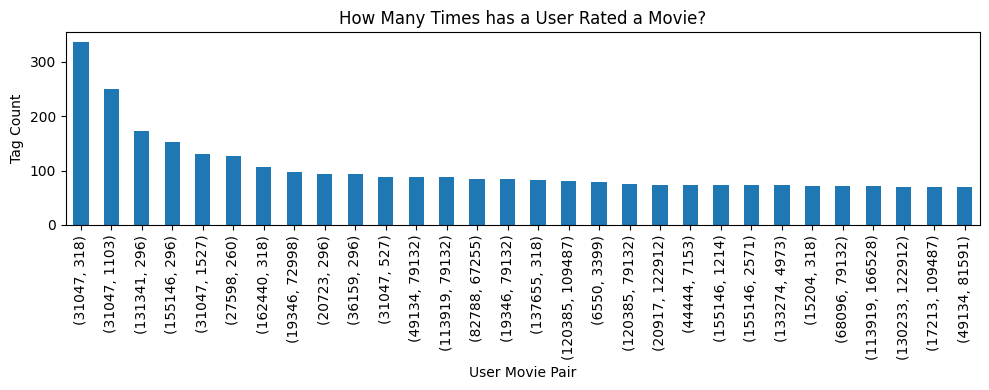

In [31]:
user_movie_tag = tags_df.groupby(['userId', 'movieId']).size()

user_movie_tag.nlargest(30).plot.bar(figsize=(10, 4))
plt.ylabel('Tag Count')
plt.xlabel('User Movie Pair')
plt.title('How Many Times has a User Rated a Movie?')
plt.tight_layout()
plt.show()

### Tags Added Overtime

<Axes: xlabel='tag_time'>

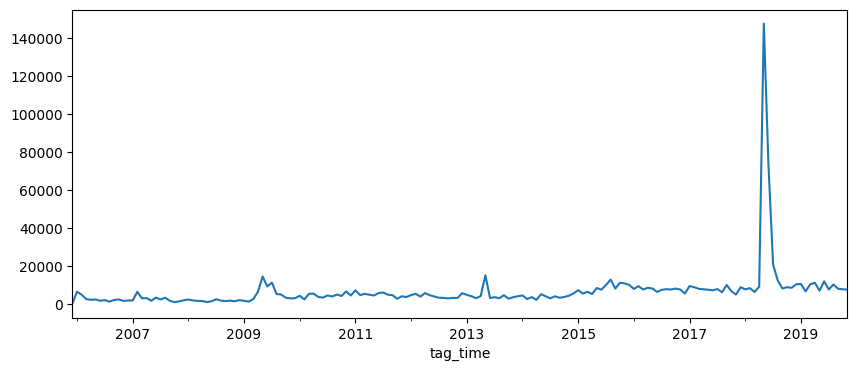

In [32]:
tags_df['tag_time'] = pd.to_datetime(tags_df['timestamp'], unit='s', utc = True)
tags_df.set_index("tag_time").resample("ME").size().plot(figsize=(10, 4))

### Rating vs Tag Counts for Movies

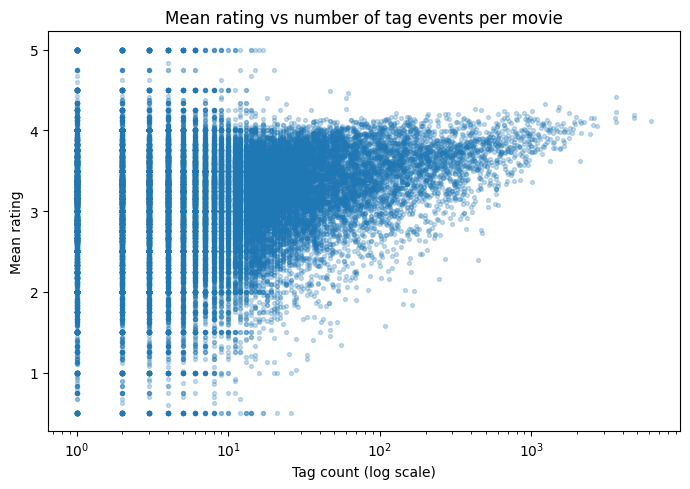

In [39]:
movie_ratings = ratings_df.groupby("movieId", as_index=False).agg(
    rating_count=("rating", "size"),
    mean_rating=("rating", "mean"),
)

movie_tags = tags_df.groupby("movieId", as_index=False).agg(
    tag_count=("tag", "size"),           # or any column, counting rows
    distinct_tags=("tag", "nunique"),
)

movies_only = movie_ratings.merge(movie_tags, on="movieId", how="outer")
# drop movies missing one side for this view
d = movies_only.dropna(subset=["mean_rating", "tag_count"])
plt.figure(figsize=(7, 5))
plt.scatter(d["tag_count"], d["mean_rating"], alpha=0.25, s=8)
plt.xscale("log")
plt.xlabel("Tag count (log scale)")
plt.ylabel("Mean rating")
plt.title("Mean rating vs number of tag events per movie")
plt.tight_layout()
plt.show()

### Ratings vs Tags Created by User 

In [ ]:
user_ratings = ratings_df.groupby("userId", as_index=False).agg(
    rating_count=("rating", "size"),
    mean_rating=("rating", "mean"),
)

user_tags = tags_df.groupby("userId", as_index=False).agg(
    tag_count=("tag", "size"),           # or any column, counting rows
    distinct_tags=("tag", "nunique"),
)

user_only = user_ratings.merge(user_tags, on="userId", how="outer")
# drop movies missing one side for this view
d = user_only.dropna(subset=["mean_rating", "tag_count"])
plt.figure(figsize=(7, 5))
plt.scatter(d["tag_count"], d["mean_rating"], alpha=0.25, s=8)
plt.xscale("log")
plt.xlabel("Tag count (log scale)")
plt.ylabel("Mean rating")
plt.title("Mean rating vs number of tag events per user")
plt.tight_layout()
plt.show()

## Genome Scores

In [ ]:
dataset_statistics(genome_scores_df, "Genome Scores Dataset")

## TMDB Request example

In [33]:
example_movie_id = links_df.iloc[0]['movieId']
example_imdb_id = f"tt{int(links_df.iloc[0]['imdbId']):07d}"
movie_name = movies_df[movies_df['movieId'] == example_movie_id]['title'].values[0]

url = f"https://api.themoviedb.org/3/find/{example_imdb_id}?external_source=imdb_id&language=en-US"
TMDB_API_KEY = os.getenv('TMDB_API_KEY')
headers = {
    "accept": "application/json",
    "Authorization": f"Bearer {TMDB_API_KEY}"
}

response = requests.get(url, headers=headers)

print(f"The movie {movie_name}'s description is: {response.json()['movie_results'][0]['overview']}")

The movie Toy Story (1995)'s description is: Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences.
